<a href="https://colab.research.google.com/github/dhrupsarkar965/data-analysis-projects/blob/main/IPL_Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
matches=pd.read_csv("/content/matches.csv")
deliveries=pd.read_csv("/content/deliveries (1).csv")

#Team Analysis

**1.Total matches played by each team**

In [62]:
total_team=pd.concat([matches['team1'],matches['team2']]).replace({'Rising Pune Supergiant':'Rising Pune Supergiants','Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings'})


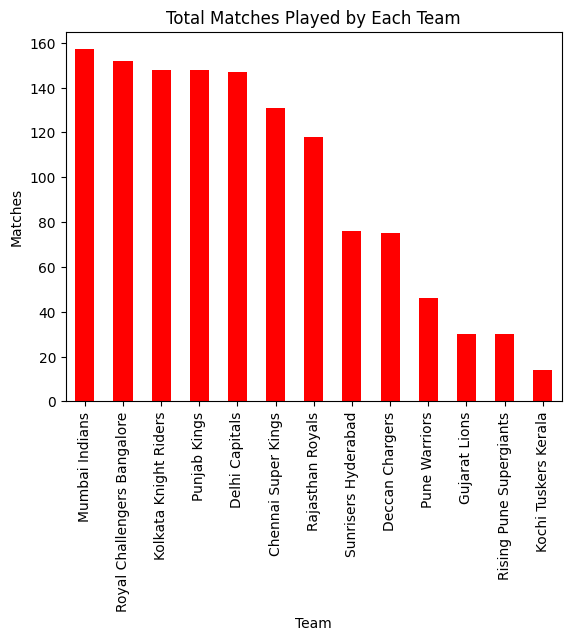

In [63]:
total_team.value_counts().plot(kind='bar',color='red')
plt.title('Total Matches Played by Each Team')
plt.xlabel('Team')
plt.ylabel('Matches')
plt.show()

**2.Win count of each team**

In [64]:
matches['winner']=matches['winner'].replace({'Rising Pune Supergiant':'Rising Pune Supergiants','Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings'})



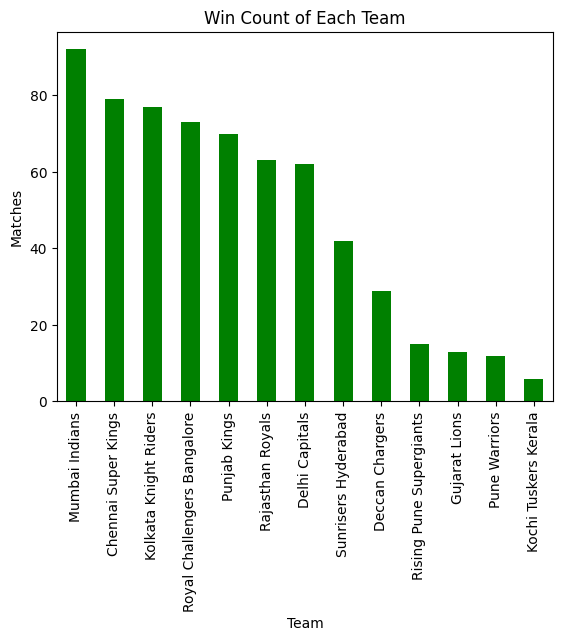

In [65]:
matches['winner'].value_counts().plot(kind='bar',color='Green')
plt.title('Win Count of Each Team')
plt.xlabel('Team')
plt.ylabel('Matches')
plt.show()

**3.Win percentage (success rate) of each team**

In [66]:
total_match_played=pd.concat([matches['team1'],matches['team2']]).replace({'Rising Pune Supergiant':'Rising Pune Supergiants','Delhi Daredevils':'Delhi Capitals','Kings XI Punjab':'Punjab Kings'})




In [67]:
succes_rate_of_team=(matches['winner'].value_counts())/(total_match_played.value_counts())*100

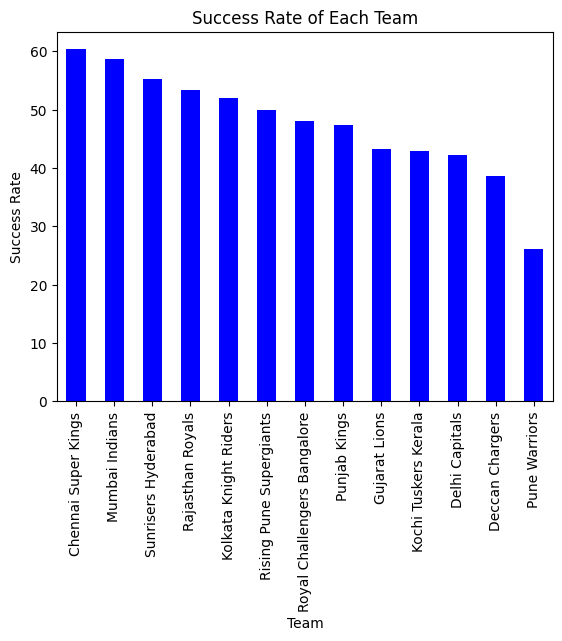

In [68]:
succes_rate_of_team.sort_values(ascending=False).plot(kind='bar',color='blue')
plt.title('Success Rate of Each Team')
plt.xlabel('Team')
plt.ylabel('Success Rate')
plt.show()

**4.Toss winner vs match winner analysis**

In [100]:
total_match_played=matches.shape[0]

In [99]:
total_toss_winner=matches[matches['toss_winner']==matches['winner']].shape[0]

In [107]:
percentage=(total_toss_winner / total_match_played )*100

In [109]:
print("The percentage of toss winner is match winner is:",percentage)

The percentage of toss winner is match winner is: 40.723270440251575


#Batting Analysis

**1.Top run scorers by battsman by (all-time and season)**

In [114]:
matches.rename(columns={'id':'match_id'},inplace=True)

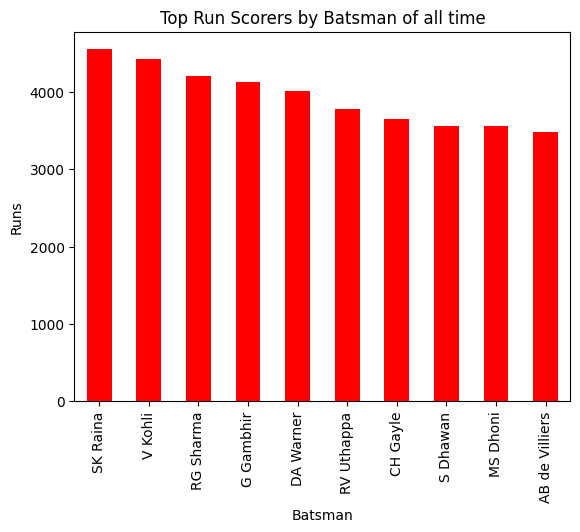

In [149]:
deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10).plot(kind='bar',color='red')
plt.title('Top Run Scorers by Batsman of all time')
plt.xlabel('Batsman')
plt.ylabel('Runs')
plt.show()

In [123]:
temp=matches.merge(deliveries,on='match_id')

In [160]:
total_runs=temp.groupby(['season','batsman'])['batsman_runs'].sum().sort_values(ascending=False).head(10).drop_duplicates(keep='first')

In [161]:
total_runs=total_runs.reset_index()

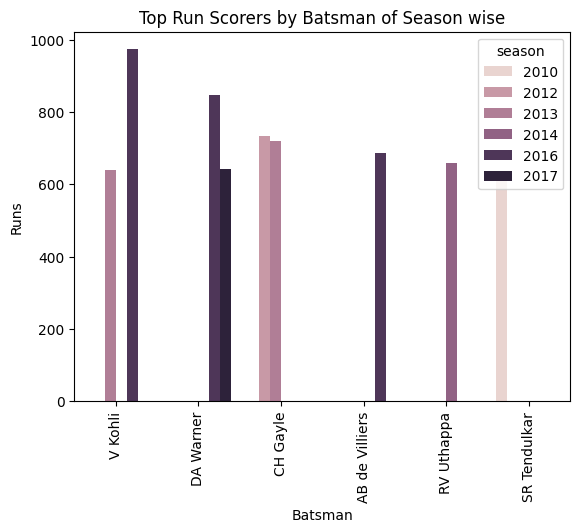

In [162]:
sns.barplot(data=total_runs,x='batsman',y='batsman_runs',hue='season')
plt.title('Top Run Scorers by Batsman of Season wise')
plt.xlabel('Batsman')
plt.ylabel('Runs')
plt.xticks(rotation=90)
plt.show()

**2.Best strike rate**

In [166]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN


In [177]:
run_scored=deliveries.groupby('batsman')['batsman_runs'].sum()

In [181]:
ball_faced=deliveries.groupby('batsman')['ball'].count()

In [182]:
strike_rate=(run_scored/ball_faced)*100.

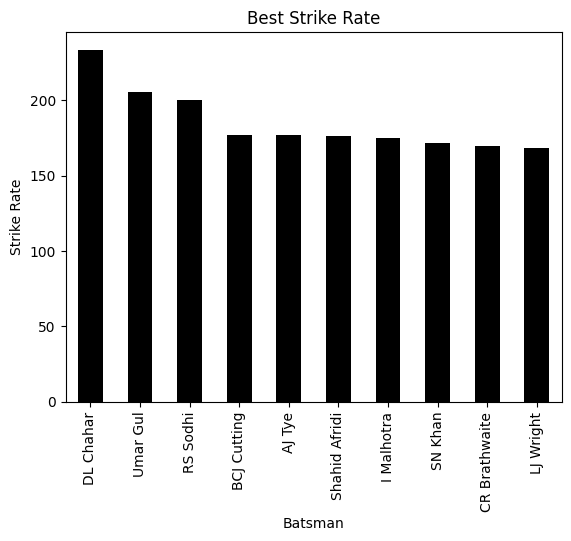

In [184]:
strike_rate.sort_values(ascending=False).head(10).plot(kind='bar',color='black')
plt.title('Best Strike Rate')
plt.xlabel('Batsman')
plt.ylabel('Strike Rate')
plt.show()

In [185]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN


**3.Most sixes and most fours hitter**

In [197]:
temp1=deliveries[(deliveries['batsman_runs']==6)|(deliveries['batsman_runs']==4)]

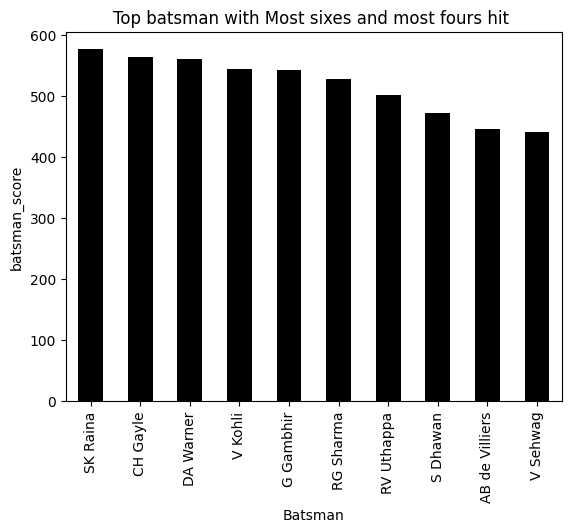

In [198]:
temp1.groupby('batsman')['batsman_runs'].count().sort_values(ascending=False).head(10).plot(kind="bar",color='black')
plt.title("Top batsman with Most sixes and most fours hit ")
plt.xlabel('Batsman')
plt.ylabel('batsman_score')
plt.show()

**4.Player consistency (average runs per match)**

In [216]:
match_played=deliveries.groupby('batsman')['match_id'].nunique()

In [218]:
total_runs=deliveries.groupby('batsman')['batsman_runs'].sum()

In [219]:
AVG=(total_runs/match_played).sort_values(ascending=False).head(10)

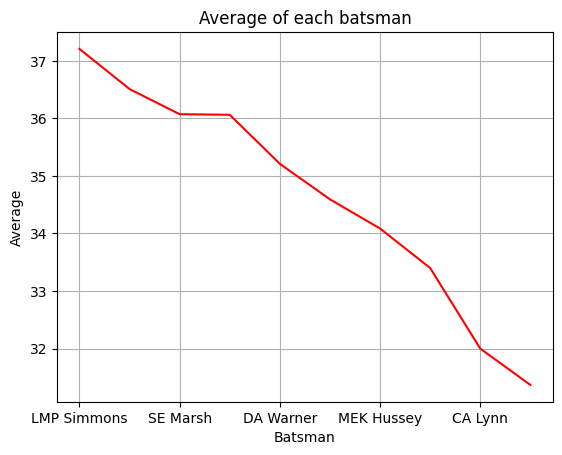

In [224]:
AVG.plot(kind='line',color='red')
plt.title('Average of each batsman')
plt.xlabel('Batsman')
plt.ylabel('Average')
plt.grid()
plt.show()

#Bowling Analysis

**1.Most Wickets Taker bowler**

In [228]:
bowler=deliveries.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

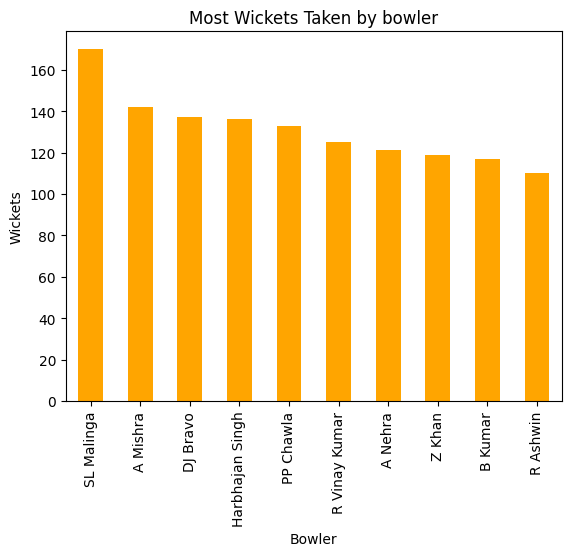

In [230]:
bowler.plot(kind='bar',color='orange')
plt.title('Most Wickets Taken by bowler')
plt.xlabel('Bowler')
plt.ylabel('Wickets')
plt.show()